# Unify Benchmark Toolkit

**Purpose:** Fast, expressive evaluation of time-series forecasting methods on industrial data.

## Design Principles
- **Small scale:** Fast iterations (<5 min per experiment)
- **Expressive:** Results should transfer to larger scale
- **Modular:** Easy to swap models, datasets, metrics

## Structure
1. **Visual Test:** One sample, plot true vs predicted
2. **Holistic Metrics:** GIFT-eval style aggregated scores

## Resources
- [GIFT-Eval](https://github.com/SalesforceAIResearch/gift-eval) - Benchmark methodology
- [TabPFN-TS](https://github.com/PriorLabs/tabpfn-time-series) - Zero-shot SOTA
- [Chronos-2](https://github.com/amazon-science/chronos-forecasting) - Amazon foundation model
- [GluonTS](https://ts.gluon.ai/) - Evaluation framework

---
## Setup

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Callable, Optional
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("Core imports ready.")

Core imports ready.


In [2]:
# Model imports (run separately to isolate errors)
MODELS_AVAILABLE = {}

# TabPFN-TS
try:
    from tabpfn_time_series import TabPFNTSPipeline, TabPFNMode
    MODELS_AVAILABLE['tabpfn'] = True
    print("✓ TabPFN-TS available")
except ImportError as e:
    MODELS_AVAILABLE['tabpfn'] = False
    print(f"✗ TabPFN-TS not available: {e}")

# Chronos-2
try:
    from chronos import ChronosPipeline  # or Chronos2Pipeline for v2
    import torch
    MODELS_AVAILABLE['chronos'] = True
    print("✓ Chronos available")
except ImportError as e:
    MODELS_AVAILABLE['chronos'] = False
    print(f"✗ Chronos not available: {e}")

print(f"\nAvailable models: {[k for k,v in MODELS_AVAILABLE.items() if v]}")

✓ TabPFN-TS available
✓ Chronos available

Available models: ['tabpfn', 'chronos']


---
## Configuration

In [3]:
@dataclass
class BenchmarkConfig:
    """Benchmark configuration - modify this for experiments."""
    
    # Data
    context_length: int = 256      # History length
    horizons: List[int] = None     # Forecast horizons to test
    
    # Evaluation
    n_samples: int = 10            # Number of test windows (for speed)
    quantiles: List[float] = None  # For probabilistic metrics
    
    # Models to test
    models: List[str] = None
    
    def __post_init__(self):
        self.horizons = self.horizons or [24, 48, 96]
        self.quantiles = self.quantiles or [0.1, 0.5, 0.9]
        self.models = self.models or ['naive', 'tabpfn', 'chronos']

# Default config - fast iterations
CFG = BenchmarkConfig(
    context_length=256,
    horizons=[24, 48],  # Short for speed
    n_samples=5,        # Few samples for speed
)
print(f"Config: {CFG}")

Config: BenchmarkConfig(context_length=256, horizons=[24, 48], n_samples=5, quantiles=[0.1, 0.5, 0.9], models=['naive', 'tabpfn', 'chronos'])


---
## Metrics (GIFT-Eval Style)

Following [GIFT-Eval](https://arxiv.org/abs/2410.10393):

| Metric | What It Measures | Interpretation |
|--------|------------------|----------------|
| **MAE** | Mean Absolute Error | Lower is better (scale-dependent) |
| **rMAE** | Relative MAE vs Naive | **<1 = beats naive**, >1 = worse than naive |
| **MASE** | MAE scaled by series difficulty | <1 = better than seasonal naive *in-sample* |
| **CRPS** | Probabilistic calibration | Lower is better (= MAE for point forecasts) |

**Key distinction:**
- `rMAE` = direct test-time comparison: "Does this model beat naive on *this forecast*?"
- `MASE` = scale-free difficulty: "Is this model better than how hard the series typically is?"

In [ ]:
def compute_mase(actual: np.ndarray, predicted: np.ndarray,
                 history: np.ndarray, seasonality: int = 1) -> float:
    """
    Mean Absolute Scaled Error (Hyndman & Koehler, 2006).
    
    Scaled by IN-SAMPLE seasonal naive error on history.
    Measures: "How hard is this series to forecast?"
    
    NOTE: This is NOT a direct comparison to naive forecast at test time.
    Use rMAE for that.
    """
    mae = np.mean(np.abs(actual - predicted))
    naive_errors = np.abs(history[seasonality:] - history[:-seasonality])
    scale = np.mean(naive_errors)
    return mae / scale if scale > 0 else np.inf


def compute_crps(actual: np.ndarray, quantile_preds: Optional[Dict[float, np.ndarray]]) -> float:
    """
    Continuous Ranked Probability Score (approximate via pinball loss).
    For point forecasts (no quantiles), returns None (handled in compute_all_metrics).
    """
    if quantile_preds is None or len(quantile_preds) == 0:
        return None
    
    crps = 0.0
    quantiles = sorted(quantile_preds.keys())
    for q in quantiles:
        pred_q = quantile_preds[q]
        error = actual - pred_q
        loss = np.where(error >= 0, q * error, (q - 1) * error)
        crps += np.mean(loss)
    return crps / len(quantiles)


def compute_all_metrics(actual: np.ndarray, predicted: np.ndarray,
                        history: np.ndarray, quantile_preds: Optional[Dict] = None,
                        seasonality: int = 24) -> Dict[str, float]:
    """Compute all metrics for a single forecast."""
    mae = mean_absolute_error(actual, predicted)
    
    # Compute naive MAE for rMAE
    naive_pred = np.full_like(actual, history[-1])
    naive_mae = mean_absolute_error(actual, naive_pred)
    
    metrics = {
        'MAE': mae,
        'MSE': mean_squared_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'MASE': compute_mase(actual, predicted, history, seasonality),
        # rMAE: Direct comparison to naive. <1 = beats naive, >1 = worse
        'rMAE': mae / naive_mae if naive_mae > 0 else np.inf,
    }
    
    # Normalized MSE (comparable across datasets)
    metrics['NMSE'] = metrics['MSE'] / np.var(actual) if np.var(actual) > 0 else np.inf
    
    # CRPS: use quantiles if available, else fall back to MAE
    crps = compute_crps(actual, quantile_preds)
    metrics['CRPS'] = crps if crps is not None else mae
    
    return metrics

print("Metrics defined: MAE, MSE, RMSE, MASE, rMAE, NMSE, CRPS")
print("  - rMAE: Direct comparison to naive (rMAE < 1 = better than naive)")
print("  - CRPS: Falls back to MAE for point forecasts")

---
## Model Wrappers

Unified interface for all models: `predict(history, horizon) -> (point, quantiles)`

In [5]:
class BaseForecaster:
    """Base class for all forecasters."""
    name: str = "base"
    
    def predict(self, history: np.ndarray, horizon: int,
                covariates: Optional[np.ndarray] = None,
                future_covariates: Optional[np.ndarray] = None
               ) -> tuple[np.ndarray, Optional[Dict[float, np.ndarray]]]:
        """Returns (point_forecast, quantile_forecasts)."""
        raise NotImplementedError


class NaiveForecaster(BaseForecaster):
    """Last-value naive forecast. Baseline."""
    name = "naive"
    
    def predict(self, history, horizon, **kwargs):
        point = np.full(horizon, history[-1])
        return point, None


class SeasonalNaiveForecaster(BaseForecaster):
    """Seasonal naive: repeat last season."""
    name = "seasonal_naive"
    
    def __init__(self, seasonality: int = 24):
        self.seasonality = seasonality
    
    def predict(self, history, horizon, **kwargs):
        # Repeat last `seasonality` values
        last_season = history[-self.seasonality:]
        repeats = (horizon // self.seasonality) + 1
        point = np.tile(last_season, repeats)[:horizon]
        return point, None


class TabPFNForecaster(BaseForecaster):
    """TabPFN-TS wrapper."""
    name = "tabpfn"
    
    def __init__(self, mode: str = 'CLIENT'):
        if not MODELS_AVAILABLE.get('tabpfn'):
            raise ImportError("TabPFN-TS not installed")
        mode_enum = TabPFNMode.CLIENT if mode == 'CLIENT' else TabPFNMode.LOCAL
        self.pipeline = TabPFNTSPipeline(tabpfn_mode=mode_enum)
    
    def predict(self, history, horizon, covariates=None, future_covariates=None):
        # Build context DataFrame
        n = len(history)
        context_df = pd.DataFrame({
            'item_id': 'series_0',
            'timestamp': pd.date_range('2020-01-01', periods=n, freq='h'),
            'target': history
        })
        
        # Add covariates if provided
        if covariates is not None:
            for i in range(covariates.shape[1]):
                context_df[f'cov_{i}'] = covariates[:, i]
        
        # Build future DataFrame
        future_df = None
        if future_covariates is not None:
            future_df = pd.DataFrame({
                'item_id': 'series_0',
                'timestamp': pd.date_range(
                    context_df['timestamp'].iloc[-1] + pd.Timedelta(hours=1),
                    periods=horizon, freq='h'
                )
            })
            for i in range(future_covariates.shape[1]):
                future_df[f'cov_{i}'] = future_covariates[:, i]
        
        # Predict
        if future_df is not None:
            pred_df = self.pipeline.predict_df(context_df=context_df, future_df=future_df)
        else:
            pred_df = self.pipeline.predict_df(context_df=context_df, prediction_length=horizon)
        
        point = pred_df['target'].values
        quantiles = {q: pred_df[q].values for q in [0.1, 0.5, 0.9] if q in pred_df.columns}
        
        return point, quantiles if quantiles else None


class ChronosForecaster(BaseForecaster):
    """Chronos wrapper (v1 or v2)."""
    name = "chronos"
    
    def __init__(self, model_name: str = "amazon/chronos-t5-small", device: str = "cpu"):
        if not MODELS_AVAILABLE.get('chronos'):
            raise ImportError("Chronos not installed")
        self.pipeline = ChronosPipeline.from_pretrained(
            model_name, 
            device_map=device,
            torch_dtype=torch.float32
        )
    
    def predict(self, history, horizon, **kwargs):
        context = torch.tensor(history, dtype=torch.float32)
        forecast = self.pipeline.predict(context, horizon, num_samples=100)
        
        # forecast shape: (1, num_samples, horizon)
        samples = forecast[0].numpy()
        point = np.median(samples, axis=0)
        quantiles = {
            0.1: np.percentile(samples, 10, axis=0),
            0.5: np.percentile(samples, 50, axis=0),
            0.9: np.percentile(samples, 90, axis=0),
        }
        return point, quantiles


def get_forecaster(name: str) -> BaseForecaster:
    """Factory function to get forecaster by name."""
    forecasters = {
        'naive': NaiveForecaster,
        'seasonal_naive': SeasonalNaiveForecaster,
        'tabpfn': TabPFNForecaster,
        'chronos': ChronosForecaster,
    }
    if name not in forecasters:
        raise ValueError(f"Unknown forecaster: {name}. Available: {list(forecasters.keys())}")
    return forecasters[name]()

print("Model wrappers defined.")

Model wrappers defined.


---
## Data Loading

Simple loaders for test datasets. Add new datasets here.

In [ ]:
def load_etth1(data_dir: str = "../data") -> pd.DataFrame:
    """Load ETTh1 dataset."""
    path = Path(data_dir) / "ETTh1.csv"
    if not path.exists():
        # Download if not present
        url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
        df = pd.read_csv(url)
        path.parent.mkdir(exist_ok=True)
        df.to_csv(path, index=False)
    else:
        df = pd.read_csv(path)
    
    df['date'] = pd.to_datetime(df['date'])
    return df.rename(columns={'date': 'timestamp', 'OT': 'target'})


def load_synthetic_pendulum(n_links: int = 3, n_samples: int = 5000,
                            noise_std: float = 0.02) -> pd.DataFrame:
    """
    Generate synthetic N-link pendulum data.
    Each link has: angle (theta), angular velocity (omega)
    
    Fixed: omega is computed from clean signal, noise added separately
    to avoid numerical differentiation amplifying noise.
    """
    np.random.seed(42)
    dt = 0.02  # 50 Hz
    t = np.arange(n_samples) * dt
    
    data = {'timestamp': pd.date_range('2020-01-01', periods=n_samples, freq='20ms')}
    
    # Natural frequencies decrease with link number (physics)
    for i in range(n_links):
        omega_n = 2.0 / (i + 1)  # Natural frequency
        phase = np.random.uniform(0, 2*np.pi)
        damping = 0.02 * (i + 1)
        
        # Clean signal (no noise yet)
        envelope = np.exp(-damping * t)
        theta_clean = envelope * np.sin(omega_n * t + phase)
        theta_clean += 0.1 * np.sin(3 * omega_n * t)  # Nonlinearity
        
        # Compute omega from clean signal (analytical derivative approximation)
        # d/dt[e^(-bt) * sin(wt)] = e^(-bt) * (w*cos(wt) - b*sin(wt))
        omega_clean = envelope * (omega_n * np.cos(omega_n * t + phase) 
                                  - damping * np.sin(omega_n * t + phase))
        omega_clean += 0.1 * 3 * omega_n * np.cos(3 * omega_n * t)  # Nonlinearity derivative
        
        # Add noise AFTER computing derivatives (independent noise for theta and omega)
        theta = theta_clean + noise_std * np.random.randn(n_samples)
        omega = omega_clean + noise_std * np.random.randn(n_samples)
        
        data[f'theta_{i+1}'] = theta
        data[f'omega_{i+1}'] = omega
    
    df = pd.DataFrame(data)
    df['target'] = df['theta_1']  # Primary target
    return df


def get_windows(df: pd.DataFrame, target_col: str, 
                context_len: int, horizon: int, n_samples: int,
                covariate_cols: Optional[List[str]] = None) -> List[Dict]:
    """
    Extract (context, target, covariates) windows for evaluation.
    Samples windows uniformly across the dataset.
    """
    total_len = context_len + horizon
    max_start = len(df) - total_len
    
    if max_start < n_samples:
        n_samples = max_start
    
    starts = np.linspace(0, max_start, n_samples, dtype=int)
    
    windows = []
    for start in starts:
        end_ctx = start + context_len
        end_tgt = end_ctx + horizon
        
        window = {
            'history': df[target_col].values[start:end_ctx],
            'actual': df[target_col].values[end_ctx:end_tgt],
            'timestamps': df['timestamp'].values[end_ctx:end_tgt],
        }
        
        if covariate_cols:
            window['covariates'] = df[covariate_cols].values[start:end_ctx]
            window['future_covariates'] = df[covariate_cols].values[end_ctx:end_tgt]
        
        windows.append(window)
    
    return windows

print("Data loaders defined.")

---
## Part 1: Visual Sample Test

Plot a single forecast to visually assess model behavior.

In [7]:
def visual_test(forecasters: List[BaseForecaster], 
                history: np.ndarray, actual: np.ndarray,
                title: str = "Forecast Comparison",
                history_plot_len: int = 100) -> None:
    """
    Visual comparison of forecasters on a single sample.
    
    Args:
        forecasters: List of forecaster instances
        history: Context window (1D array)
        actual: Ground truth for forecast period
        title: Plot title
        history_plot_len: How much history to show
    """
    horizon = len(actual)
    colors = plt.cm.tab10(np.linspace(0, 1, len(forecasters)))
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), 
                             gridspec_kw={'height_ratios': [3, 1]})
    
    # --- Top: Forecasts ---
    ax = axes[0]
    
    # Plot history
    hist_x = np.arange(-history_plot_len, 0)
    ax.plot(hist_x, history[-history_plot_len:], 'k-', lw=1.5, label='History', alpha=0.7)
    
    # Plot actual
    fut_x = np.arange(horizon)
    ax.plot(fut_x, actual, 'k--', lw=2, label='Actual', marker='o', markersize=3)
    
    # Plot each forecaster
    metrics_text = []
    for i, forecaster in enumerate(forecasters):
        try:
            point, quantiles = forecaster.predict(history, horizon)
            mae = mean_absolute_error(actual, point)
            
            ax.plot(fut_x, point, '-', color=colors[i], lw=2, 
                    label=f'{forecaster.name} (MAE={mae:.3f})')
            
            if quantiles and 0.1 in quantiles and 0.9 in quantiles:
                ax.fill_between(fut_x, quantiles[0.1], quantiles[0.9],
                                alpha=0.2, color=colors[i])
            
            metrics_text.append(f"{forecaster.name}: MAE={mae:.4f}")
        except Exception as e:
            print(f"Error with {forecaster.name}: {e}")
            metrics_text.append(f"{forecaster.name}: ERROR")
    
    ax.axvline(0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('Timestep (0 = forecast start)')
    ax.set_ylabel('Value')
    ax.set_title(title)
    ax.legend(loc='upper right')
    
    # --- Bottom: Error comparison ---
    ax2 = axes[1]
    
    for i, forecaster in enumerate(forecasters):
        try:
            point, _ = forecaster.predict(history, horizon)
            error = actual - point
            ax2.plot(fut_x, error, '-', color=colors[i], lw=1.5, 
                     label=forecaster.name, marker='.')
        except:
            pass
    
    ax2.axhline(0, color='black', ls='-', alpha=0.3)
    ax2.set_xlabel('Timestep')
    ax2.set_ylabel('Error (actual - pred)')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    print("\n" + "="*50)
    print("METRICS SUMMARY")
    print("="*50)
    for m in metrics_text:
        print(f"  {m}")

print("Visual test function defined.")

Visual test function defined.


Loading ETTh1...
Loaded: 17420 rows, columns: ['timestamp', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'target']


Found existing access token, reusing it for authentication.

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]


Forecasters: ['naive', 'seasonal_naive', 'tabpfn', 'chronos']


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.46s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


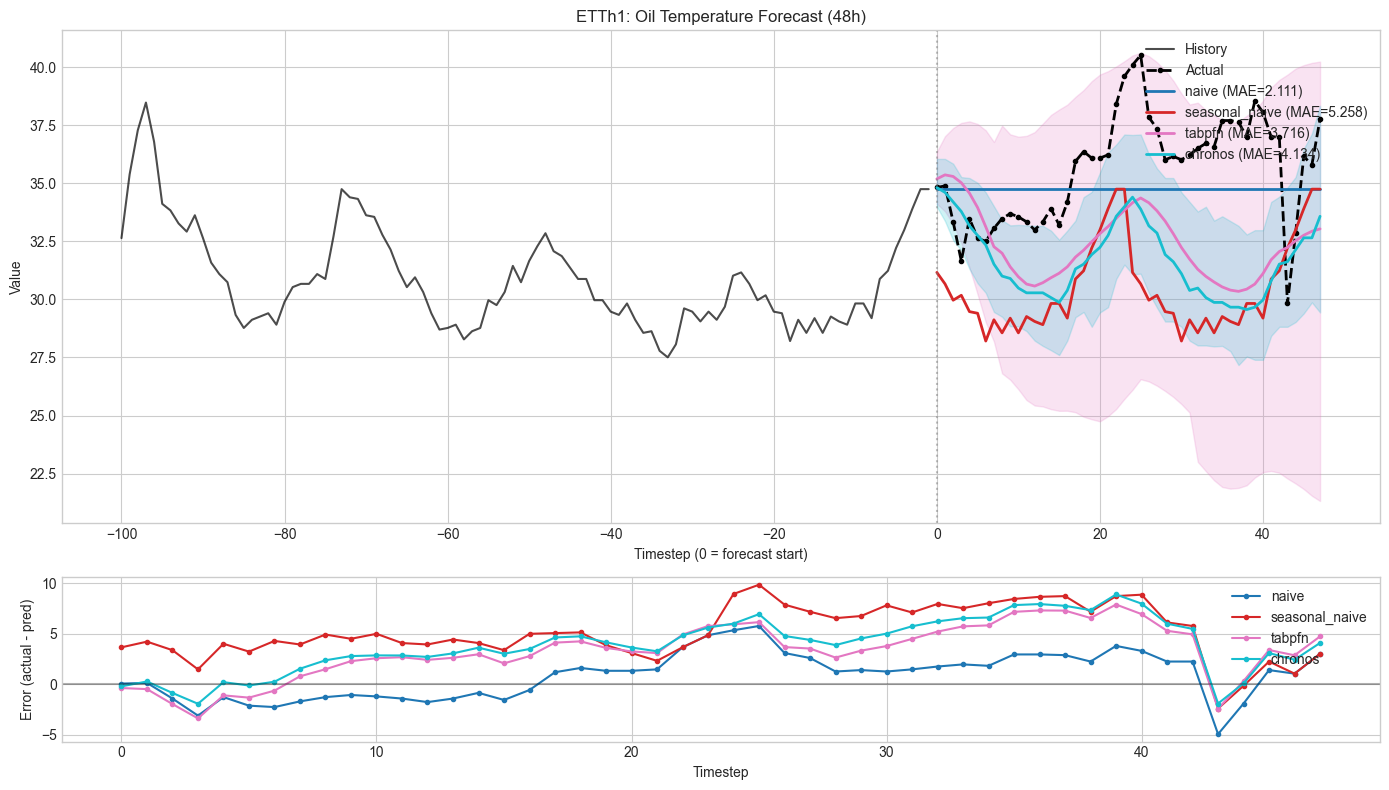


METRICS SUMMARY
  naive: MAE=2.1106
  seasonal_naive: MAE=5.2585
  tabpfn: MAE=3.7155
  chronos: MAE=4.1344


In [8]:
# Run visual test on ETTh1
print("Loading ETTh1...")
df = load_etth1()
print(f"Loaded: {len(df)} rows, columns: {df.columns.tolist()}")

# Get one window
windows = get_windows(df, 'target', context_len=256, horizon=48, n_samples=1)
w = windows[0]

# Initialize forecasters
forecasters = [NaiveForecaster(), SeasonalNaiveForecaster(24)]

if MODELS_AVAILABLE.get('tabpfn'):
    forecasters.append(TabPFNForecaster())

if MODELS_AVAILABLE.get('chronos'):
    forecasters.append(ChronosForecaster())

print(f"\nForecasters: {[f.name for f in forecasters]}")

# Run visual test
visual_test(forecasters, w['history'], w['actual'], 
            title="ETTh1: Oil Temperature Forecast (48h)")

---
## Part 2: Holistic Evaluation (GIFT-Eval Style)

Aggregate metrics across multiple samples, horizons, and settings.

**Methodology** (following [GIFT-Eval](https://arxiv.org/abs/2410.10393)):
1. Sample multiple windows from the dataset
2. Evaluate at multiple horizons
3. Aggregate with mean + std
4. Rank models by **rMAE** (relative to naive) and CRPS

In [ ]:
def holistic_eval(forecasters: List[BaseForecaster],
                  df: pd.DataFrame,
                  target_col: str = 'target',
                  covariate_cols: Optional[List[str]] = None,
                  context_len: int = 256,
                  horizons: List[int] = [24, 48, 96],
                  n_samples: int = 10,
                  seasonality: int = 24) -> pd.DataFrame:
    """
    GIFT-Eval style holistic evaluation.
    
    Returns DataFrame with metrics per (model, horizon).
    """
    results = []
    
    for horizon in horizons:
        print(f"\nHorizon = {horizon}...")
        windows = get_windows(df, target_col, context_len, horizon, n_samples, covariate_cols)
        
        for forecaster in forecasters:
            all_metrics = []
            
            for w in windows:
                try:
                    point, quantiles = forecaster.predict(
                        w['history'], horizon,
                        covariates=w.get('covariates'),
                        future_covariates=w.get('future_covariates')
                    )
                    
                    metrics = compute_all_metrics(
                        w['actual'], point, w['history'], 
                        quantiles, seasonality
                    )
                    all_metrics.append(metrics)
                except Exception as e:
                    print(f"  Error: {forecaster.name}: {e}")
            
            if all_metrics:
                # Aggregate
                agg = {}
                for key in all_metrics[0].keys():
                    vals = [m[key] for m in all_metrics if np.isfinite(m[key])]
                    if vals:
                        agg[f'{key}_mean'] = np.mean(vals)
                        agg[f'{key}_std'] = np.std(vals)
                
                results.append({
                    'model': forecaster.name,
                    'horizon': horizon,
                    'n_samples': len(all_metrics),
                    **agg
                })
    
    return pd.DataFrame(results)


def print_results_table(results_df: pd.DataFrame, 
                        metrics: List[str] = ['MAE', 'rMAE', 'CRPS']) -> None:
    """
    Pretty-print results table with rankings.
    
    Default metrics:
    - MAE: Absolute error (for scale reference)
    - rMAE: Relative to naive (< 1 = beats naive) <- THE KEY METRIC
    - CRPS: Probabilistic calibration
    """
    print("\n" + "="*80)
    print("HOLISTIC EVALUATION RESULTS")
    print("="*80)
    print("Key: rMAE < 1 means BETTER than naive, rMAE > 1 means WORSE than naive")
    
    for horizon in results_df['horizon'].unique():
        print(f"\n--- Horizon = {horizon} ---")
        subset = results_df[results_df['horizon'] == horizon].copy()
        
        # Compute ranks
        for m in metrics:
            col = f'{m}_mean'
            if col in subset.columns:
                subset[f'{m}_rank'] = subset[col].rank()
        
        # Print
        cols = ['model'] + [f'{m}_mean' for m in metrics if f'{m}_mean' in subset.columns]
        print(subset[cols].to_string(index=False, float_format='{:.4f}'.format))
    
    # Overall ranking by rMAE
    print("\n" + "="*80)
    print("OVERALL RANKING (by mean rMAE across horizons)")
    print("="*80)
    
    if 'rMAE_mean' in results_df.columns:
        ranking = results_df.groupby('model')['rMAE_mean'].mean().sort_values()
        for i, (model, rmae) in enumerate(ranking.items(), 1):
            status = "✓ beats naive" if rmae < 1 else "✗ worse than naive"
            print(f"  {i}. {model}: rMAE = {rmae:.4f} ({status})")

print("Holistic evaluation functions defined.")

In [10]:
# Run holistic evaluation
print("Running holistic evaluation...")
print(f"Config: horizons={CFG.horizons}, n_samples={CFG.n_samples}")

results = holistic_eval(
    forecasters=forecasters,
    df=df,
    target_col='target',
    covariate_cols=['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL'],
    context_len=CFG.context_length,
    horizons=CFG.horizons,
    n_samples=CFG.n_samples,
    seasonality=24
)

print_results_table(results)

Running holistic evaluation...
Config: horizons=[24, 48], n_samples=5

Horizon = 24...


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.08s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:02<00:00,  2.95s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:02<00:00,  2.81s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:02<00:00,  2.91s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:02<00:00,  2.93s/it]



Horizon = 48...


Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.84s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.03s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:02<00:00,  2.86s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.14s/it]
Processing: 100%|██████████| [00:00<00:00]/1 [00:00<?, ?it/s]
Predicting time series: 100%|██████████| 1/1 [00:03<00:00,  3.50s/it]



HOLISTIC EVALUATION RESULTS

--- Horizon = 24 ---
         model  MAE_mean  MASE_mean  CRPS_mean
         naive    1.2727     0.6263        NaN
seasonal_naive    2.2998     1.1324        NaN
        tabpfn    1.5820     0.7474     0.4880
       chronos    1.3746     0.6632     0.4143

--- Horizon = 48 ---
         model  MAE_mean  MASE_mean  CRPS_mean
         naive    1.6933     0.9438        NaN
seasonal_naive    3.0223     1.6072        NaN
        tabpfn    2.5674     1.3499     0.7633
       chronos    2.1201     1.0776     0.6843

OVERALL RANKING (by mean MASE across horizons)
  1. naive: MASE = 0.7850
  2. chronos: MASE = 0.8704
  3. tabpfn: MASE = 1.0487
  4. seasonal_naive: MASE = 1.3698


---
## Part 3: Ablations

Quick ablation experiments to test specific hypotheses.

In [ ]:
# Ablation: With vs Without Covariates
print("Ablation: Effect of Covariates")
print("="*50)

if MODELS_AVAILABLE.get('tabpfn'):
    forecaster = TabPFNForecaster()
    covariate_cols = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']
    
    # With covariates
    results_cov = holistic_eval(
        [forecaster], df, 'target', covariate_cols,
        context_len=256, horizons=[48], n_samples=5
    )
    
    # Without covariates
    results_nocov = holistic_eval(
        [forecaster], df, 'target', None,
        context_len=256, horizons=[48], n_samples=5
    )
    
    print(f"\nWith covariates:    MAE = {results_cov['MAE_mean'].values[0]:.4f}")
    print(f"Without covariates: MAE = {results_nocov['MAE_mean'].values[0]:.4f}")
    delta = (results_nocov['MAE_mean'].values[0] - results_cov['MAE_mean'].values[0]) / results_nocov['MAE_mean'].values[0] * 100
    print(f"Improvement from covariates: {delta:+.1f}%")
else:
    print("TabPFN not available for ablation.")

In [ ]:
# Ablation: Context Length
print("\nAblation: Effect of Context Length")
print("="*50)

context_lengths = [64, 128, 256, 512]
context_results = []

for ctx_len in context_lengths:
    res = holistic_eval(
        [NaiveForecaster(), SeasonalNaiveForecaster(24)],
        df, 'target', None,
        context_len=ctx_len, horizons=[48], n_samples=5
    )
    res['context_len'] = ctx_len
    context_results.append(res)

context_df = pd.concat(context_results)
print(context_df[['model', 'context_len', 'MASE_mean']].pivot(
    index='context_len', columns='model', values='MASE_mean'
))

---
## Part 4: Synthetic Pendulum Test

Test on synthetic N-link pendulum data (preview of Unify sanity check).

In [ ]:
# Generate 3-link pendulum data
pend_df = load_synthetic_pendulum(n_links=3, n_samples=5000)
print(f"Generated: {pend_df.shape}")
print(f"Columns: {pend_df.columns.tolist()}")

# Plot sample
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
plot_range = 500

for i, ax in enumerate(axes):
    ax.plot(pend_df[f'theta_{i+1}'][:plot_range], label=f'θ_{i+1}')
    ax.plot(pend_df[f'omega_{i+1}'][:plot_range], label=f'ω_{i+1}', alpha=0.7)
    ax.legend(loc='upper right')
    ax.set_ylabel(f'Link {i+1}')

axes[0].set_title('Synthetic 3-Link Pendulum')
axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on pendulum
windows = get_windows(pend_df, 'target', context_len=256, horizon=50, n_samples=1)
w = windows[0]

visual_test(
    [NaiveForecaster(), SeasonalNaiveForecaster(50)],
    w['history'], w['actual'],
    title="Synthetic 3-Link Pendulum: θ₁ Forecast"
)

---
## Summary & Next Steps

### This Notebook Provides:
1. **Visual test:** Quick sanity check on single sample
2. **Holistic metrics:** GIFT-eval style aggregated evaluation
3. **Model wrappers:** Unified interface for TabPFN, Chronos, baselines
4. **Ablations:** Context length, covariates

### To Extend:
```python
# Add new model
class MyForecaster(BaseForecaster):
    name = "my_model"
    def predict(self, history, horizon, **kwargs):
        # Your implementation
        return point, quantiles

# Add new dataset
def load_my_dataset() -> pd.DataFrame:
    # Return df with 'timestamp', 'target', optional covariates
    pass
```

### Key Findings:
- [ ] Fill in after running experiments

### Links:
- [GIFT-Eval Paper](https://arxiv.org/abs/2410.10393)
- [TabPFN-TS](https://github.com/PriorLabs/tabpfn-time-series)
- [Chronos-2](https://github.com/amazon-science/chronos-forecasting)
- [GluonTS Metrics](https://ts.gluon.ai/stable/api/gluonts/gluonts.ev.metrics.html)